# 03 - Look at those lightcurves

In [1]:
import lsdb
from lsdb import ConeSearch
from nested_pandas.utils import count_nested
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dask.distributed import print as dask_print
from dask.distributed import Client
from nested_pandas.utils import count_nested
from dask.distributed import print as dask_print
import dask

lsdb.show_versions()


--------      SYSTEM INFO      --------
python        : 3.12.11
python-bits   : 64
OS            : Linux
OS-release    : 5.14.0-570.58.1.el9_6.x86_64
Version       : #1 SMP PREEMPT_DYNAMIC Fri Oct 31 13:55:05 UTC 2025
machine       : x86_64
processor     : 
byteorder     : little
LC_ALL        : 
LANG          : 
--------   INSTALLED VERSIONS   --------
lsdb          : 0.8.2
hats          : 0.8.2
nested-pandas : 0.6.8
pandas        : 2.3.1
numpy         : 2.4.2
dask          : 2025.7.0
pyarrow       : 17.0.0
fsspec        : 2025.7.0


In [2]:
lc_cat = lsdb.open_catalog("./lcs")
lc_cat

,coord_dec,coord_ra,objectId,g_psfFlux,g_psfFluxErr,i_psfFlux,i_psfFluxErr,r_psfFlux,r_psfFluxErr,u_psfFlux,u_psfFluxErr,y_psfFlux,y_psfFluxErr,z_psfFlux,z_psfFluxErr,lc_u,n_lc_u,lc_g,n_lc_g,lc_r,n_lc_r,lc_i,n_lc_i,lc_z,n_lc_z,lc_y,n_lc_y
npartitions=4,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 9, Pixel: 2299635",double[pyarrow],double[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],"nested<band: [string], detector: [int16], inva...",int32[pyarrow],"nested<band: [string], detector: [int16], inva...",int32[pyarrow],"nested<band: [string], detector: [int16], inva...",int32[pyarrow],"nested<band: [string], detector: [int16], inva...",int32[pyarrow],"nested<band: [string], detector: [int16], inva...",int32[pyarrow],"nested<band: [string], detector: [int16], inva...",int32[pyarrow]
"Order: 9, Pixel: 2299638",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 9, Pixel: 2299641",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Order: 9, Pixel: 2299644",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [28]:
def detector_hist(frame, pixel):
    histos = {}
    
    for band in "ugrizy":
        histos[band] = np.histogram(frame[f"lc_{band}.detector"], bins=np.arange(190))[0]
    # print(histos)
    # return histos
    histos["pixel"] = pixel

    return pd.DataFrame([histos])

In [29]:
# my_data = lc_cat.head(10)
# single_result = detector_hist(my_data)

In [30]:
all_results = lc_cat.map_partitions(detector_hist, include_pixel=True).compute()
all_results

,u,g,r,i,z,y,pixel
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[0, 0, 0, 0, 0, 948, 0, 1, 656, 0, 0, 0, 5414, 2544, 0, 836, 1259, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 418, 26765, 0, 740, 6094, 0, 4153, 0, 0, 0, 0, 8512, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4275, 0, 0, 0, 0, 0, 0, 0, 0, 95, 0, 1507, 2217, 0, 0, 5181, 12064, 0, 50624, 4139, 0, 0, 0, 4431, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[0, 0, 0, 0, 0, 2285, 0, 0, 3346, 0, 0, 0, 5862, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 33, 0, 4106, 11126, 25794, 0, 436, 0, 0, 0, 0, 0, 0, 4164, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3529, 4889, 94, 2598, 1495, 4298, 18193, 8413, 0, 0, 0, 0, 0, 0, 5727, 2567, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1515, 2520, 0, 2818, 4318, 0, 6019, 2494, 0, 4823, 0, 229, 6232, 3256, 0, 15589, 7818, 0, 0, 0, 0, 0, 25793, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4016, 0, 0, 0, 0, 0, 0, 0, 7557, 587, 791, 41, 0, 170, 0, 4299, 3912, 0, 0, 0, 3682, 4299, 0, 329, 0, 0, 0, 4923, 8081, 0, 53048, 5264, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[0, 0, 3954, 0, 0, 66, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1895, 6050, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3812, 1804, 26681, 3137, 0, 0, 0, 0, 0, 0, 0, 0, 6266, 1744, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 171, 2208, 0, 10599, 9301, 0, 14873, 8977, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","Order: 9, Pixel: 2299635"
0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[0, 0, 0, 0, 0, 0, 0, 0, 1298, 0, 0, 0, 810, 0, 0, 5507, 4203, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 8866, 0, 0, 4523, 0, 4167, 0, 13657, 0, 0, 8759, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 209, 3854, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4203, 0, 0, 0, 0, 15049, 0, 5674, 50322, 0, 0, 0, 8445, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[0, 0, 0, 0, 0, 0, 0, 0, 1407, 0, 0, 0, 1473, 0, 0, 4346, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 10553, 13356, 5577, 4172, 2476, 214, 0, 3157, 0, 0, 4063, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 810, 6249, 0, 1331, 4203, 0, 8166, 25218, 2442, 0, 0, 0, 0, 0, 3542, 7782, 97, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 64, 35, 0, 1772, 5212, 0, 8776, 658, 0, 0, 0, 4667, 6946, 0, 1224, 8866, 8279, 0, 0, 0, 0, 0, 10119, 0, 0, 23, 0, 0, 0, 11414, 0, 0, 375, 0, 0, 0, 1682, 260, 0, 4002, 0, 0, 0, 0, 2537, 5015, 3531, 5049, 0, 448, 260, 4217, 4277, 0, 0, 0, 1399, 3138, 0, 1212, 6, 0, 0, 0, 11383, 0, 6156, 52668, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[0, 0, 18, 0, 0, 3945, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2267, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 24, 4441, 14167, 6588, 0, 3439, 1104, 0, 0, 0, 0, 0, 7797, 4165, 0, 1362, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 600, 2543, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 60, 3099, 0, 3440, 14357, 0, 0, 25218, 257, 0, 0, 1162, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [31]:
len(all_results["g"].to_numpy()[0])

189

In [33]:
summaries = {}

for band in "ugrizy":
    summary = np.zeros(189)
    for single in all_results[band].to_numpy():
        summary = np.add(summary, single)
    
    summaries[band] = summary

# summaries

## Detections by band, binned in detector

In [34]:
detector_simplified_xy = pd.read_csv("detector_simplified_xy.csv")
detector_simplified_xy

,id,x,y
0,0,3,0
1,1,4,0
...,...,...,...
187,187,10,14
188,188,11,14


Text(0.5, 0.98, 'Count of observations, per LSSTCam Detector')

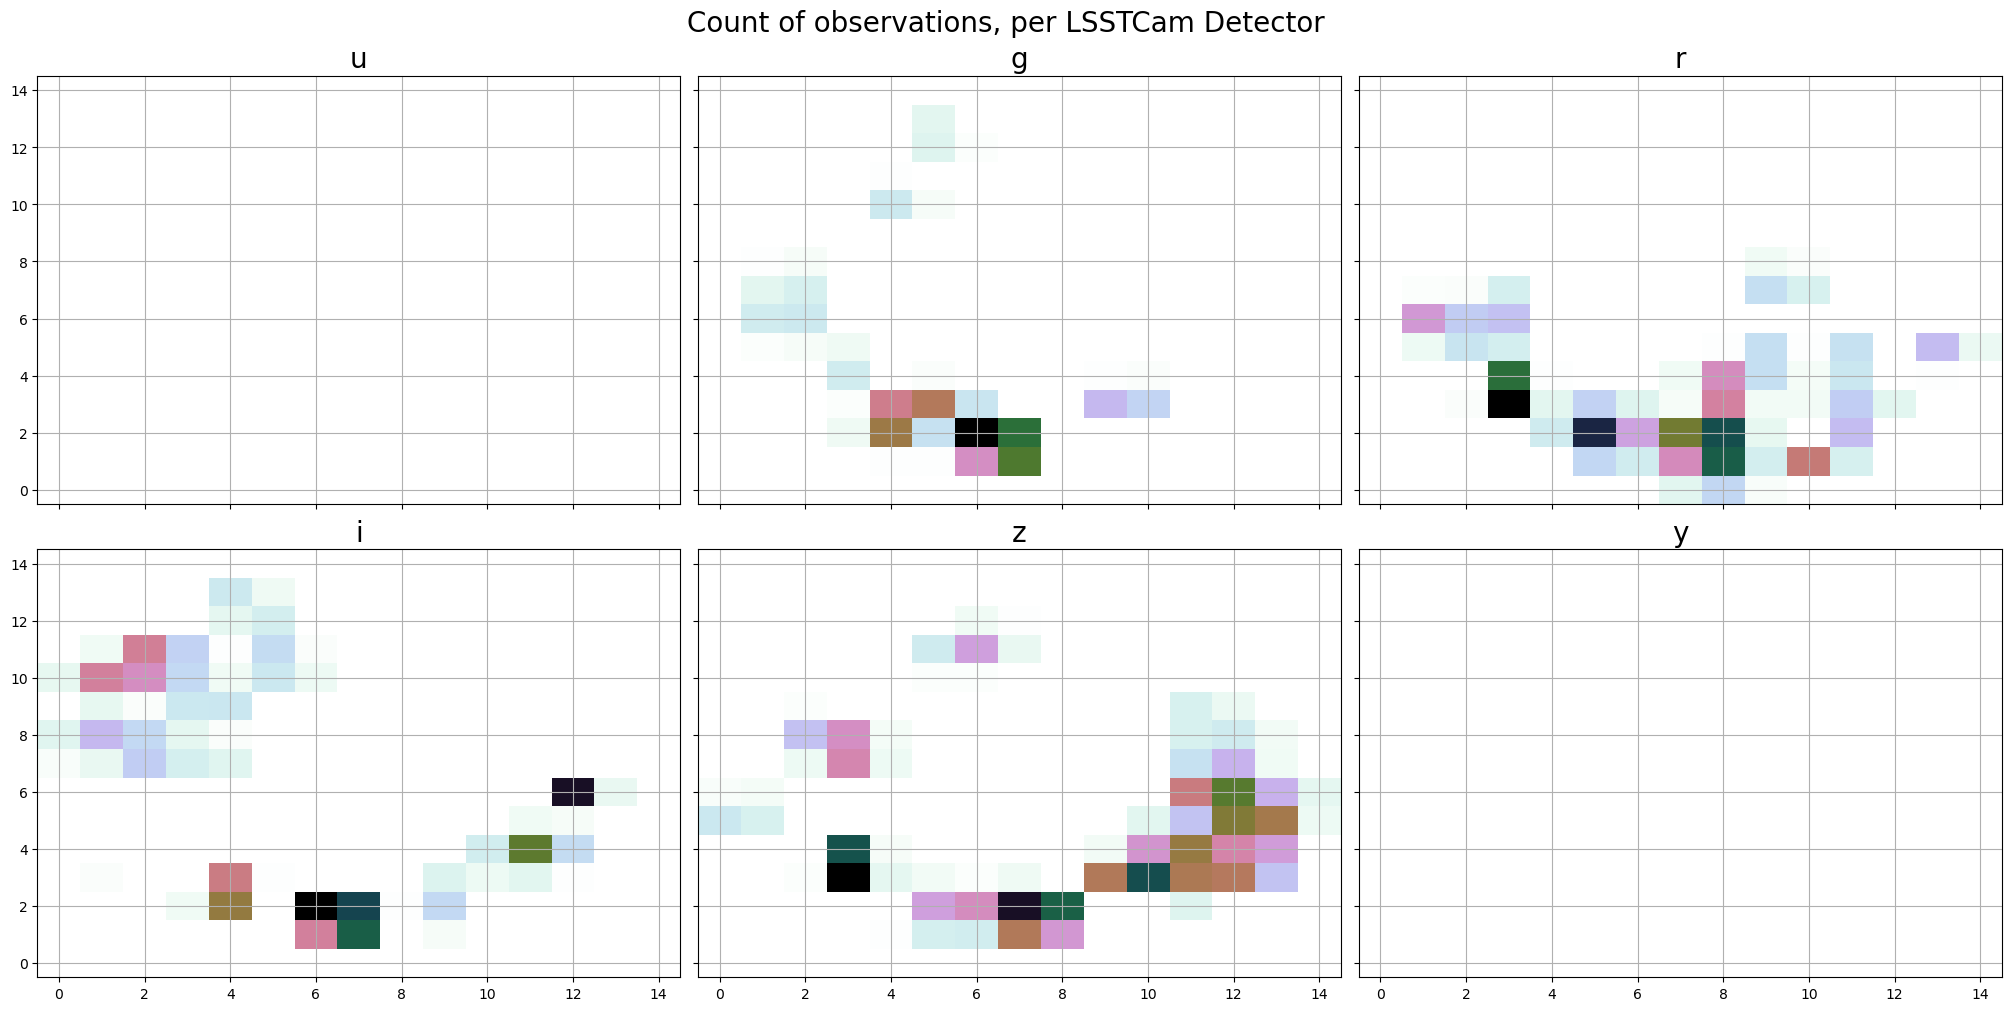

In [35]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10), sharex=True, sharey=True, layout="constrained")

x = np.arange(0, 15)
y = np.arange(0, 15)

for ax, band in zip(axs.flat, 'ugrizy'):
    rec_array = np.full((15,15), 0)
    for bin_value, bin_count in enumerate(summaries[band]):
        rec_array[detector_simplified_xy["x"][bin_value]][detector_simplified_xy["y"][bin_value]] = bin_count

    ax.pcolormesh(x, y, rec_array, cmap='cubehelix_r')
    ax.set_title(band, fontsize=20)
    ax.grid()

fig.suptitle("Count of observations, per LSSTCam Detector", fontsize=20)